In [152]:
from utils_gene import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Taille du fichier : 182851 octets
Graphe initial : Nodes : 198, Edges : 2742
Variance cible (SBM) : 0.04838831
------------------------------
 Alpha trouvé : 3.5734 pour 2742.0 liens visés.
Step 01 | Sigma testé: 19.1014 | Var: 0.07397459 | Δ: 2.56e-02
 Alpha trouvé : 5.8435 pour 2742.0 liens visés.
Step 02 | Sigma testé: 30.9036 | Var: 0.09026740 | Δ: 4.19e-02
 Alpha trouvé : 2.0446 pour 2742.0 liens visés.
Step 03 | Sigma testé: 11.8072 | Var: 0.05342612 | Δ: 5.04e-03
 Alpha trouvé : 0.9173 pour 2742.0 liens visés.
Step 04 | Sigma testé: 7.2992 | Var: 0.03153702 | Δ: 1.69e-02
 Alpha trouvé : 2.0679 pour 2742.0 liens visés.
Step 05 | Sigma testé: 11.9099 | Var: 0.05382468 | Δ: 5.44e-03
 Alpha trouvé : 1.8355 pour 2742.0 liens visés.
Step 06 | Sigma testé: 10.9021 | Var: 0.04972889 | Δ: 1.34e-03
 Alpha trouvé : 1.5034 pour 2742.0 liens visés.
Step 07 | Sigma testé: 9.5259 | Var: 0.04343891 | Δ: 4.95e-03
 Alpha trouvé : 1.7775 pour 2742.0 liens visés.
Step 08 | Sigma testé: 10.6562 | Va

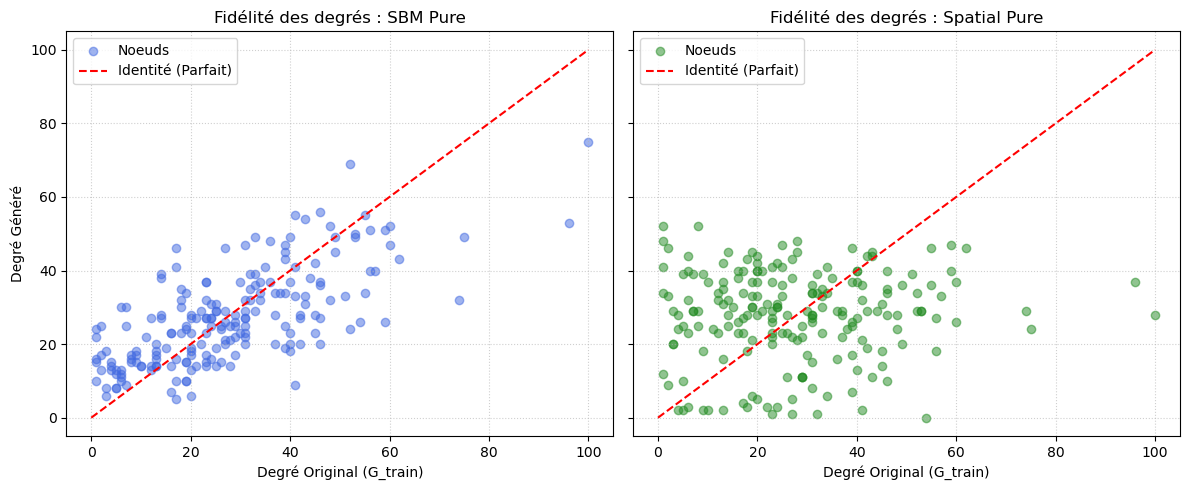

Erreur Moyenne Absolue (MAE) SBM     : 9.71
Erreur Moyenne Absolue (MAE) Spatial : 16.69
Proba moyenne pour les arêtes réelles : 0.482797
Proba min pour une arête réelle : 0.002253055850
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.488469
Proba min pour une arête réelle : 0.003952569170
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [154]:
G_name = "reel_jazz_collab_w_attributes.joblib"
path = f"../../graph_library/{G_name}"
print(f"Taille du fichier : {os.path.getsize(path)} octets")

G = joblib.load(path)
print(f"Graphe initial : Nodes : {G.number_of_nodes()}, Edges : {G.number_of_edges()}")

e_rs, k, commus = get_real_graph_properties_sbm_V2(G)
P_sbm = get_probs_sbm_non_DC(e_rs, commus)
#P_sbm = get_probs_sbm_DC(e_rs, k , commus)

degrees, position = get_real_graph_properties_pos_V2(G)
sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees, position, DC=False)
P_spatial = get_probs_spatial_non_DC(position, n_liens_target= G.number_of_edges(), sigma = sigma_opt)
#P_spatial = get_probs_spatial_DC(degrees, position, sigma = sigma_opt)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, commus, e_rs)
g_sbm_nx = convert_to_nx_with_metadata(g_sbm, position, commus, e_rs, P_sbm)


print(f"P_SBM : {P_sbm[2][3]}")
print(f"P_SBM : {P_sbm[3][2]}")

nu = g_spatial_nx.nodes[0]
print(f"DEBUG: Attr cherché: | Présents dans nu: {list(nu.keys())}")

print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")

plot_degree_correlation(k, g_sbm, g_spatial)
#visualize_generation_diagnostics_v2(P_sbm, P_spatial, k, e_rs, b)

analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

In [156]:
Hybrid_ratios_list = np.arange(0.00, 1.25, 0.25)

generate_graph_benchmarks(Hybrid_ratios_list, P_sbm, P_spatial, position, commus, e_rs, name="artificial_graph_sbmv4", save_P_matrix=True)


Pour ratio_sbm = 0.0

ERROR : Échec de l'ajout de P_hybrid_matrix !
   ⚠️ Erreur Paire(35,143) | Blocs 2-8: Recalc=0.015571 vs P=0.068026
   ⚠️ Erreur Paire(73,81) | Blocs 6-7: Recalc=0.280000 vs P=0.082751
   ⚠️ Erreur Paire(105,116) | Blocs 10-10: Recalc=0.690909 vs P=0.157587
   ⚠️ Erreur Paire(59,183) | Blocs 2-1: Recalc=0.126598 vs P=0.709520
   ⚠️ Erreur Paire(88,109) | Blocs 10-8: Recalc=0.486631 vs P=0.028441

--- RÉSULTAT DU CHECK (200 paires) ---
❌ INCOHÉRENCE : 200/200 erreurs détectées.
❌ Différence maximale constatée : 0.8191407549
----------------------------------------
Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_0_00_pos_1_00.graphml
ID SBM : 15 (Type: <class 'int'>)
Position : [0.9229296, 0.7010399, 0.7365564, 0.17676583]

Pour ratio_sbm = 0.25

ERROR : Échec de l'ajout de P_hybrid_matrix !
   ⚠️ Erreur Paire(13,97) | Blocs 14-8: Recalc=0.000000 vs P=0.136437
   ⚠️ Erreur Paire(59,64) | Blocs 2-1: Recalc=0.126598 vs P=0.045624
   ⚠️ Er

Graphe chargé : 198 nœuds et 2738 liens.


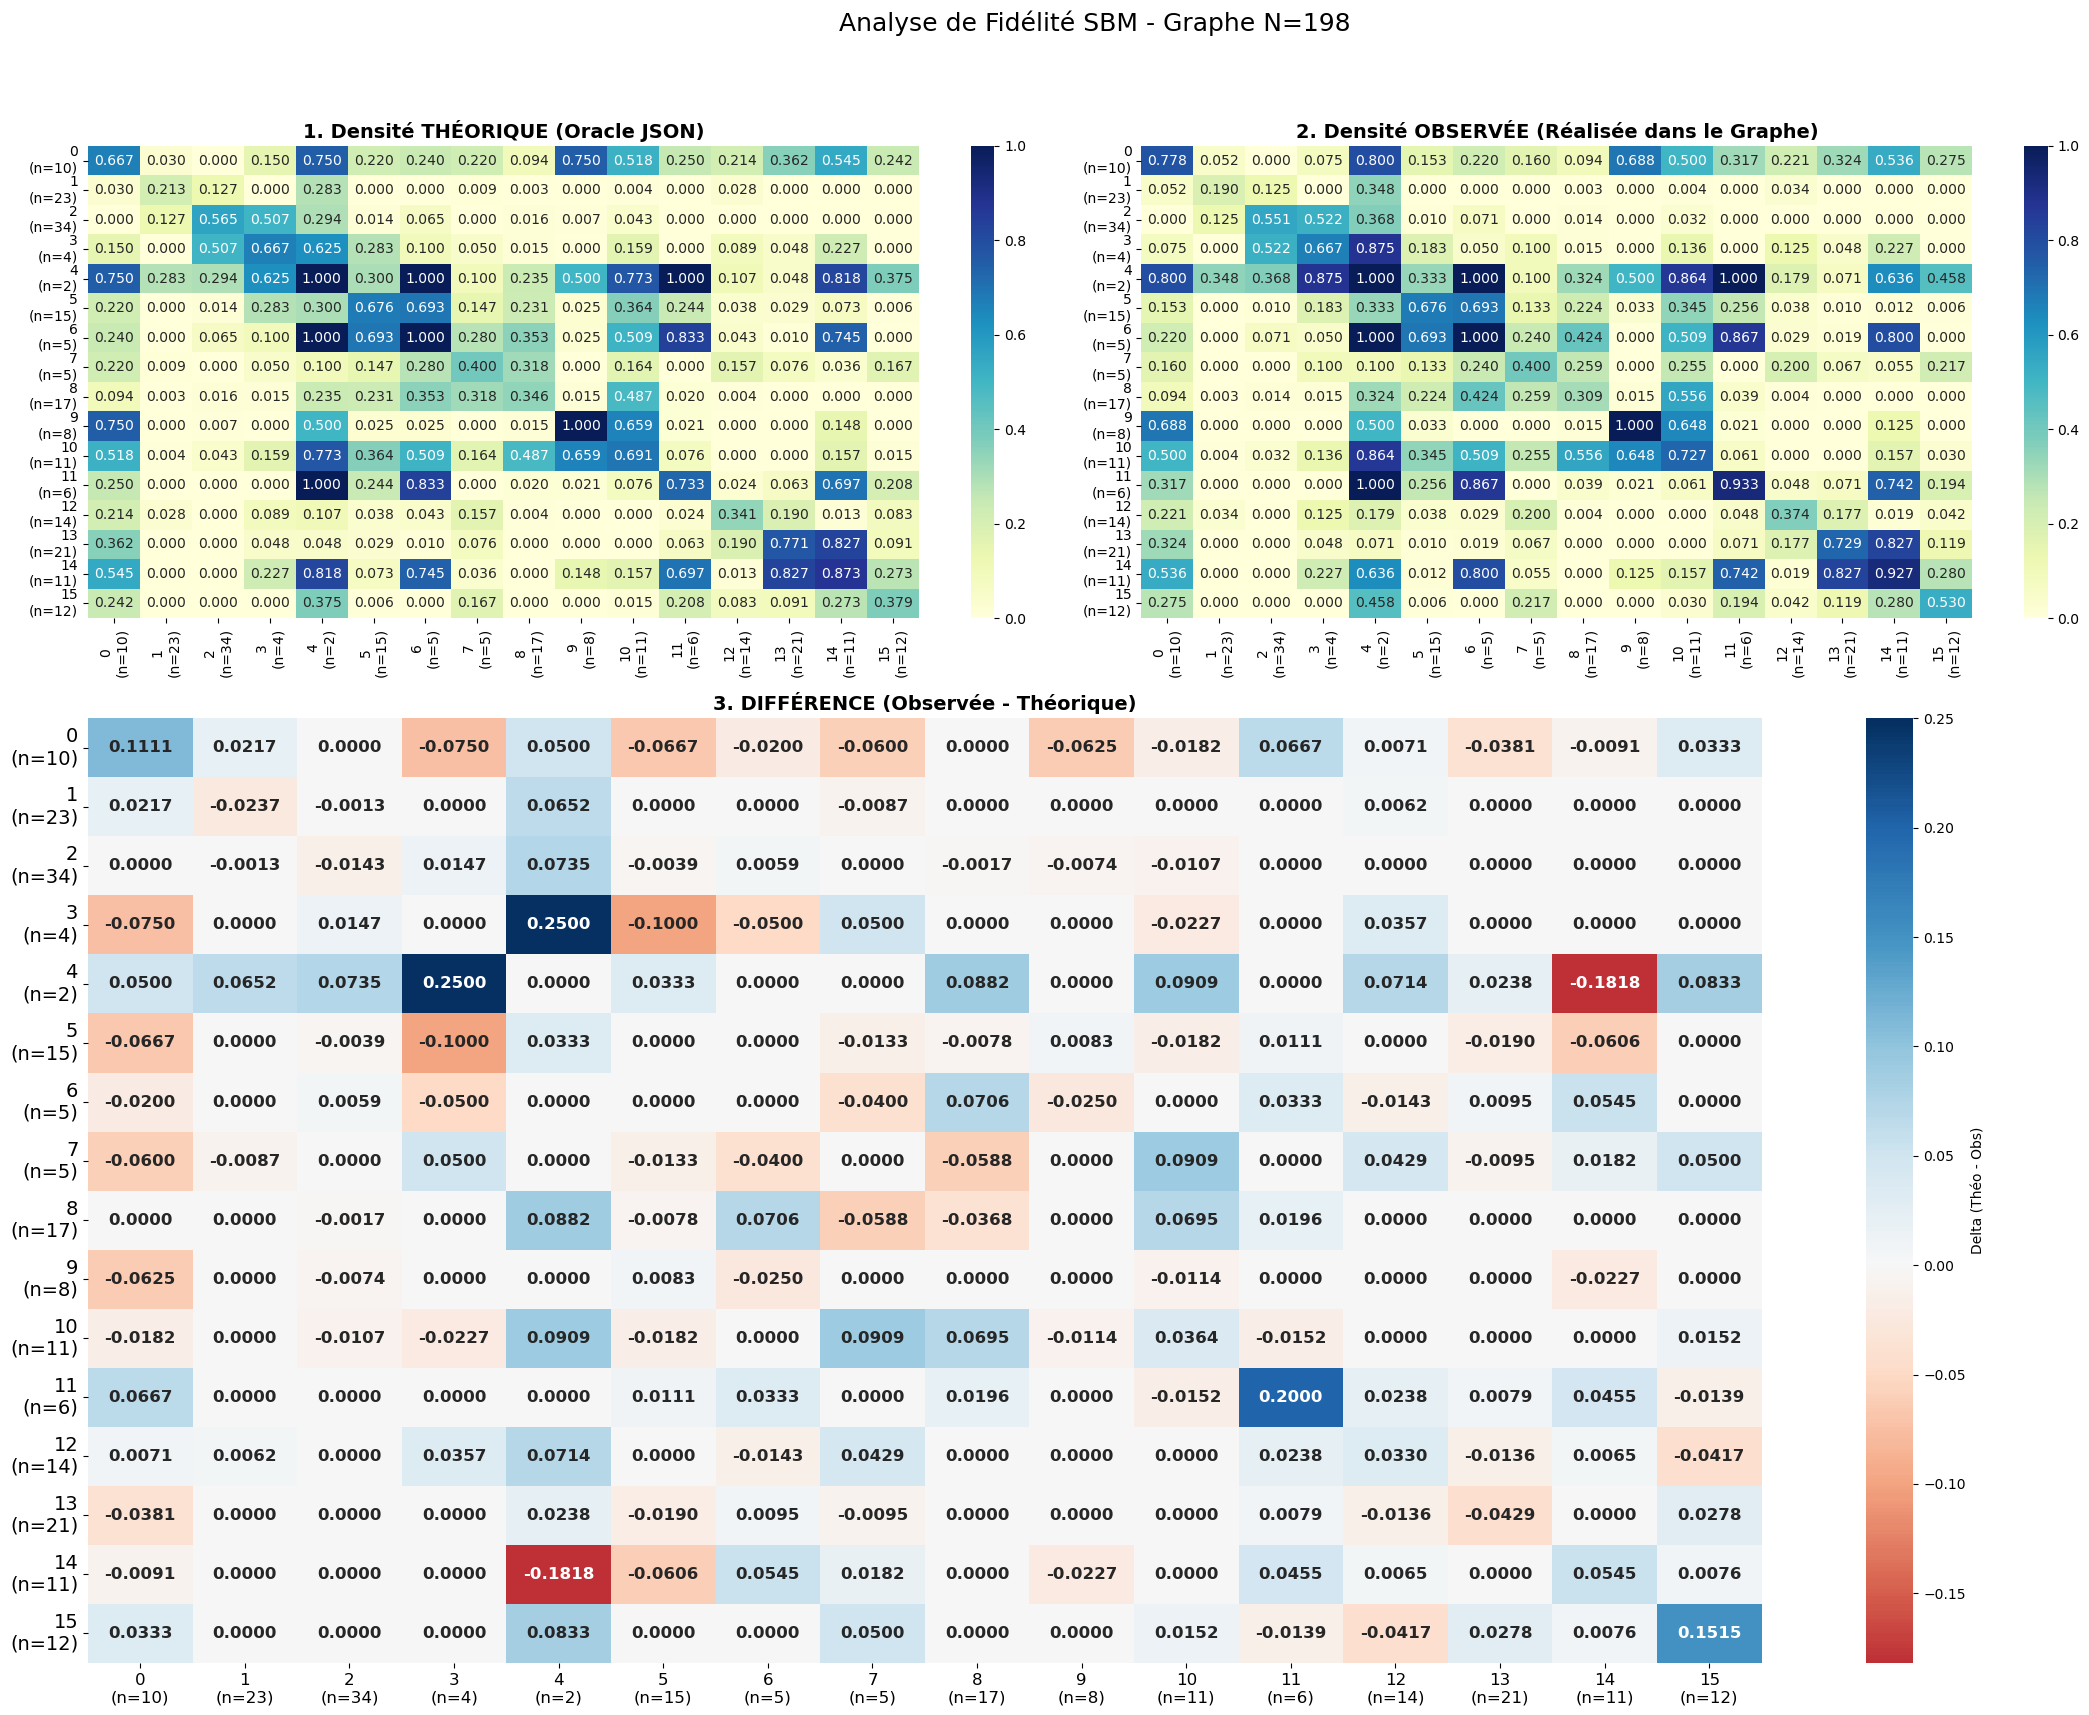

--- Rapport de Fidélité ---
Erreur Absolue Moyenne (MAE) : 0.024678
Max d'écart sur un bloc : 0.250000


In [157]:
G = load_graphml_safe("../../graph_library/artificial_graph_sbmv4_1_00_pos_0_00.graphml")
plot_sbm_density_comparison(G)